In [ ]:
# =========================
# PART 1: YELP REVIEW POLARITY - LSA EXTRACTIVE SUMMARISATION
# 1, 3, 5, 7 sentence summaries
# Predefined train/test + stratified validation split from train
# Save outputs to Google Drive
# =========================

!pip install -q pandas numpy nltk scikit-learn rouge-score

import os
import re
import time
import json
import numpy as np
import pandas as pd
import nltk

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from rouge_score import rouge_scorer

from google.colab import drive
drive.mount('/content/drive')

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# =========================
# 1. PATHS / CONFIG
# =========================
TRAIN_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/train.csv"
TEST_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/test.csv"
OUTPUT_DIR = "/content/drive/MyDrive/yelp_lsa_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
VAL_SIZE = 0.1
SUMMARY_SENTENCE_COUNTS = [1, 3, 5, 7]
CHECKPOINT_EVERY = 5000
EVAL_SAMPLE_SIZE = None   # set e.g. 2000 for faster eval if needed

print("Output folder:", OUTPUT_DIR)

# =========================
# 2. LOAD DATASET
# =========================
train_df = pd.read_csv(TRAIN_PATH, header=None, names=["label", "text"])
test_df = pd.read_csv(TEST_PATH, header=None, names=["label", "text"])

print("Original shapes:")
print("train.csv:", train_df.shape)
print("test.csv :", test_df.shape)

# Original labels: 1=negative, 2=positive
label_map = {1: 0, 2: 1}
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

# =========================
# 3. PREPROCESSING
# =========================
def clean_text(text):
    text = str(text)
    text = text.replace("<br />", " ")
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["text"] = train_df["text"].astype(str).apply(clean_text)
test_df["text"] = test_df["text"].astype(str).apply(clean_text)

train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["text"].str.len() > 0].reset_index(drop=True)

print("\nAfter cleaning:")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# =========================
# 4. STRATIFIED VALIDATION SPLIT
# =========================
train_split_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    stratify=train_df["label"],
    random_state=SEED,
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nSplit sizes:")
print("Train:", len(train_split_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

print("\nLabel distributions:")
print("Train:\n", train_split_df["label"].value_counts(normalize=True).sort_index())
print("Val:\n", val_df["label"].value_counts(normalize=True).sort_index())
print("Test:\n", test_df["label"].value_counts(normalize=True).sort_index())

# Save exact splits used
train_split_df.to_csv(os.path.join(OUTPUT_DIR, "train_split_used.csv"), index=False)
val_df.to_csv(os.path.join(OUTPUT_DIR, "val_split_used.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "test_split_used.csv"), index=False)

# =========================
# 5. LSA SUMMARY FUNCTION
# =========================
def lsa_summaries_all(text, ks=[1, 3, 5, 7]):
    sentences = sent_tokenize(str(text))

    if len(sentences) == 0:
        return {k: "" for k in ks}

    if len(sentences) == 1:
        return {k: sentences[0] for k in ks}

    try:
        vectorizer = TfidfVectorizer(stop_words="english")
        X = vectorizer.fit_transform(sentences)

        if X.shape[0] < 2 or X.shape[1] < 2:
            return {k: " ".join(sentences[:min(k, len(sentences))]) for k in ks}

        n_components = 1
        svd = TruncatedSVD(n_components=n_components, random_state=SEED)
        sentence_vectors = svd.fit_transform(X)
        scores = sentence_vectors[:, 0]

        ranked_indices = np.argsort(scores)[::-1]

        results = {}
        for k in ks:
            top_k = ranked_indices[:min(k, len(sentences))]
            top_k_sorted = sorted(top_k)
            results[k] = " ".join([sentences[i] for i in top_k_sorted])

        return results

    except Exception:
        return {k: " ".join(sentences[:min(k, len(sentences))]) for k in ks}

# =========================
# 6. CHECKPOINT HELPERS
# =========================
def get_checkpoint_path(split_name):
    return os.path.join(OUTPUT_DIR, f"{split_name}_lsa_checkpoint.json")

def get_partial_csv_path(split_name, k):
    return os.path.join(OUTPUT_DIR, f"{split_name}_lsa_{k}_sentences_partial.csv")

def save_checkpoint(split_name, idx, summaries_dict, labels):
    checkpoint = {
        "last_completed_index": idx
    }
    with open(get_checkpoint_path(split_name), "w") as f:
        json.dump(checkpoint, f)

    for k, summaries in summaries_dict.items():
        partial_df = pd.DataFrame({
            "summary_text": summaries,
            "label": labels[:len(summaries)]
        })
        partial_df.to_csv(get_partial_csv_path(split_name, k), index=False)

def load_checkpoint(split_name):
    checkpoint_path = get_checkpoint_path(split_name)
    if not os.path.exists(checkpoint_path):
        return -1, {1: [], 3: [], 5: [], 7: []}

    with open(checkpoint_path, "r") as f:
        checkpoint = json.load(f)

    summaries_dict = {}
    for k in SUMMARY_SENTENCE_COUNTS:
        partial_path = get_partial_csv_path(split_name, k)
        if os.path.exists(partial_path):
            temp_df = pd.read_csv(partial_path)
            summaries_dict[k] = temp_df["summary_text"].tolist()
        else:
            summaries_dict[k] = []

    return checkpoint["last_completed_index"], summaries_dict

# =========================
# 7. GENERATE SUMMARIES
# =========================
def generate_split_summaries(texts, labels, split_name):
    last_completed_index, summaries_dict = load_checkpoint(split_name)
    start_idx = last_completed_index + 1

    if start_idx > 0:
        print(f"\nResuming {split_name} from index {start_idx}...")

    start_time = time.time()

    for i in range(start_idx, len(texts)):
        result = lsa_summaries_all(texts[i], ks=SUMMARY_SENTENCE_COUNTS)

        for k in SUMMARY_SENTENCE_COUNTS:
            summaries_dict[k].append(result[k])

        if (i + 1) % CHECKPOINT_EVERY == 0:
            save_checkpoint(split_name, i, summaries_dict, labels)
            print(f"{split_name}: checkpoint saved at {i+1}/{len(texts)}")

    generation_time = time.time() - start_time

    final_dfs = {}
    for k in SUMMARY_SENTENCE_COUNTS:
        out_df = pd.DataFrame({
            "summary_text": summaries_dict[k],
            "label": labels
        })
        save_path = os.path.join(OUTPUT_DIR, f"{split_name}_lsa_{k}_sentences.csv")
        out_df.to_csv(save_path, index=False)
        final_dfs[k] = out_df
        print(f"Saved: {save_path}")

    save_checkpoint(split_name, len(texts) - 1, summaries_dict, labels)

    print(f"\n{split_name} generation time: {generation_time:.2f} sec")
    return final_dfs, generation_time

# =========================
# 8. RUN SUMMARY GENERATION
# =========================
train_texts = train_split_df["text"].tolist()
val_texts = val_df["text"].tolist()
test_texts = test_df["text"].tolist()

train_labels = train_split_df["label"].tolist()
val_labels = val_df["label"].tolist()
test_labels = test_df["label"].tolist()

train_summaries, train_time = generate_split_summaries(train_texts, train_labels, "train")
val_summaries, val_time = generate_split_summaries(val_texts, val_labels, "val")
test_summaries, test_time = generate_split_summaries(test_texts, test_labels, "test")

# =========================
# 9. SHOW SAMPLE OUTPUT
# =========================
if len(train_texts) > 0:
    print("\n================ SAMPLE ================\n")
    print("Original text:\n")
    print(train_texts[0][:800])

    for k in SUMMARY_SENTENCE_COUNTS:
        print(f"\n{k}-sentence summary:\n")
        print(train_summaries[k].iloc[0]['summary_text'][:800])

# =========================
# 10. EVALUATION
# =========================
def evaluate_extractive_summaries(original_texts, summary_texts, dataset_name):
    original_word_counts = []
    summary_word_counts = []
    original_sentence_counts = []
    summary_sentence_counts = []

    rouge1_scores = []
    rouge2_scores = []
    rougel_scores = []
    bleu_scores = []

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    smoothie = SmoothingFunction().method1

    if EVAL_SAMPLE_SIZE is not None and len(original_texts) > EVAL_SAMPLE_SIZE:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(original_texts), size=EVAL_SAMPLE_SIZE, replace=False)
        original_eval = [original_texts[i] for i in idx]
        summary_eval = [summary_texts[i] for i in idx]
    else:
        original_eval = original_texts
        summary_eval = list(summary_texts)

    for original, summary in zip(original_eval, summary_eval):
        original = str(original)
        summary = str(summary)

        orig_words = len(word_tokenize(original))
        summ_words = len(word_tokenize(summary))
        orig_sents = len(sent_tokenize(original))
        summ_sents = len(sent_tokenize(summary))

        original_word_counts.append(orig_words)
        summary_word_counts.append(summ_words)
        original_sentence_counts.append(orig_sents)
        summary_sentence_counts.append(summ_sents)

        try:
            scores = scorer.score(original, summary)
            rouge1_scores.append(scores["rouge1"].fmeasure)
            rouge2_scores.append(scores["rouge2"].fmeasure)
            rougel_scores.append(scores["rougeL"].fmeasure)
        except Exception:
            rouge1_scores.append(np.nan)
            rouge2_scores.append(np.nan)
            rougel_scores.append(np.nan)

        try:
            reference = [word_tokenize(original)]
            candidate = word_tokenize(summary)
            bleu = sentence_bleu(reference, candidate, smoothing_function=smoothie)
            bleu_scores.append(bleu)
        except Exception:
            bleu_scores.append(np.nan)

    avg_original_words = np.mean(original_word_counts)
    avg_summary_words = np.mean(summary_word_counts)
    avg_original_sentences = np.mean(original_sentence_counts)
    avg_summary_sentences = np.mean(summary_sentence_counts)

    word_compression_ratio = avg_summary_words / avg_original_words if avg_original_words > 0 else np.nan
    sentence_compression_ratio = avg_summary_sentences / avg_original_sentences if avg_original_sentences > 0 else np.nan

    result = {
        "dataset": dataset_name,
        "avg_original_words": round(avg_original_words, 2),
        "avg_summary_words": round(avg_summary_words, 2),
        "avg_original_sentences": round(avg_original_sentences, 2),
        "avg_summary_sentences": round(avg_summary_sentences, 2),
        "word_compression_ratio": round(word_compression_ratio, 4),
        "sentence_compression_ratio": round(sentence_compression_ratio, 4),
        "rouge_1": round(np.nanmean(rouge1_scores), 4),
        "rouge_2": round(np.nanmean(rouge2_scores), 4),
        "rouge_L": round(np.nanmean(rougel_scores), 4),
        "bleu": round(np.nanmean(bleu_scores), 4),
    }

    print("\n================================")
    print("EVALUATION:", dataset_name)
    print("================================")
    for k, v in result.items():
        if k != "dataset":
            print(f"{k}: {v}")

    return result

# =========================
# 11. RUN EVALUATION
# =========================
evaluation_results = []

for split_name, texts, summaries in [
    ("train", train_texts, train_summaries),
    ("val", val_texts, val_summaries),
    ("test", test_texts, test_summaries),
]:
    for k in SUMMARY_SENTENCE_COUNTS:
        evaluation_results.append(
            evaluate_extractive_summaries(
                texts,
                summaries[k]["summary_text"].tolist(),
                f"{split_name}_lsa_{k}_sentences"
            )
        )

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_path = os.path.join(OUTPUT_DIR, "lsa_extractive_summary_evaluation.csv")
evaluation_df.to_csv(evaluation_path, index=False)

print("\nSaved evaluation results:")
print(evaluation_path)
display(evaluation_df)

# =========================
# 12. GENERATION TIME SUMMARY
# =========================
time_df = pd.DataFrame([
    {"split": "train", "generation_time_sec": train_time},
    {"split": "val", "generation_time_sec": val_time},
    {"split": "test", "generation_time_sec": test_time},
])
time_path = os.path.join(OUTPUT_DIR, "lsa_generation_times.csv")
time_df.to_csv(time_path, index=False)

print("\nSaved generation times:")
print(time_path)
display(time_df)

print("\nAll Yelp LSA summary CSV files generated successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output folder: /content/drive/MyDrive/yelp_lsa_outputs


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original shapes:
train.csv: (560000, 2)
test.csv : (38000, 2)

After cleaning:
Train shape: (559994, 2)
Test shape : (38000, 2)

Split sizes:
Train: 503994
Val  : 56000
Test : 38000

Label distributions:
Train:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Val:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
Test:
 label
0    0.5
1    0.5
Name: proportion, dtype: float64
train: checkpoint saved at 5000/503994
train: checkpoint saved at 10000/503994
train: checkpoint saved at 15000/503994
train: checkpoint saved at 20000/503994
train: checkpoint saved at 25000/503994
train: checkpoint saved at 30000/503994
train: checkpoint saved at 35000/503994
train: checkpoint saved at 40000/503994
train: checkpoint saved at 45000/503994


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_truncated_svd.py:273: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = exp_var / full_var


train: checkpoint saved at 50000/503994
train: checkpoint saved at 55000/503994
train: checkpoint saved at 60000/503994
train: checkpoint saved at 65000/503994
train: checkpoint saved at 70000/503994
train: checkpoint saved at 75000/503994
train: checkpoint saved at 80000/503994
train: checkpoint saved at 85000/503994
train: checkpoint saved at 90000/503994
train: checkpoint saved at 95000/503994
train: checkpoint saved at 100000/503994
train: checkpoint saved at 105000/503994
train: checkpoint saved at 110000/503994
train: checkpoint saved at 115000/503994
train: checkpoint saved at 120000/503994
train: checkpoint saved at 125000/503994
train: checkpoint saved at 130000/503994
train: checkpoint saved at 135000/503994
train: checkpoint saved at 140000/503994
train: checkpoint saved at 145000/503994
train: checkpoint saved at 150000/503994
train: checkpoint saved at 155000/503994
train: checkpoint saved at 160000/503994
train: checkpoint saved at 165000/503994
train: checkpoint saved at

...

val: checkpoint saved at 40000/56000
val: checkpoint saved at 45000/56000
val: checkpoint saved at 50000/56000
val: checkpoint saved at 55000/56000
Saved: /content/drive/MyDrive/yelp_lsa_outputs/val_lsa_1_sentences.csv
Saved: /content/drive/MyDrive/yelp_lsa_outputs/val_lsa_3_sentences.csv
Saved: /content/drive/MyDrive/yelp_lsa_outputs/val_lsa_5_sentences.csv
Saved: /content/drive/MyDrive/yelp_lsa_outputs/val_lsa_7_sentences.csv

val generation time: 201.55 sec
test: checkpoint saved at 5000/38000
test: checkpoint saved at 10000/38000
test: checkpoint saved at 15000/38000
test: checkpoint saved at 20000/38000
test: checkpoint saved at 25000/38000
test: checkpoint saved at 30000/38000
test: checkpoint saved at 35000/38000
Saved: /content/drive/MyDrive/yelp_lsa_outputs/test_lsa_1_sentences.csv
Saved: /content/drive/MyDrive/yelp_lsa_outputs/test_lsa_3_sentences.csv
Saved: /content/drive/MyDrive/yelp_lsa_outputs/test_lsa_5_sentences.csv
Saved: /content/drive/MyDrive/yelp_lsa_outputs/test_ls

,dataset,avg_original_words,avg_summary_words,avg_original_sentences,avg_summary_sentences,word_compression_ratio,sentence_compression_ratio,rouge_1,rouge_2,rouge_L,bleu
0,train_lsa_1_sentences,153.22,20.57,8.51,1.03,0.1342,0.1206,0.3282,0.3132,0.3282,0.1095
1,train_lsa_3_sentences,153.22,55.52,8.51,2.87,0.3623,0.3379,0.6578,0.6437,0.6578,0.4391
2,train_lsa_5_sentences,153.22,83.48,8.51,4.37,0.5448,0.5138,0.8167,0.8071,0.8167,0.6729
3,train_lsa_7_sentences,153.22,103.38,8.51,5.47,0.6747,0.6429,0.8951,0.8887,0.8951,0.8043
4,val_lsa_1_sentences,153.21,20.47,8.53,1.03,0.1336,0.1202,0.3279,0.3129,0.3279,0.1092
5,val_lsa_3_sentences,153.21,55.37,8.53,2.88,0.3614,0.3369,0.6570,0.6429,0.6570,0.4377
6,val_lsa_5_sentences,153.21,83.39,8.53,4.37,0.5443,0.5123,0.8156,0.8060,0.8156,0.6710
7,val_lsa_7_sentences,153.21,103.26,8.53,5.48,0.6740,0.6415,0.8941,0.8876,0.8941,0.8026
8,test_lsa_1_sentences,152.60,20.54,8.48,1.03,0.1346,0.1210,0.3287,0.3139,0.3287,0.1102
9,test_lsa_3_sentences,152.60,55.63,8.48,2.87,0.3646,0.3387,0.6584,0.6443,0.6584,0.4395



Saved generation times:
/content/drive/MyDrive/yelp_lsa_outputs/lsa_generation_times.csv


,split,generation_time_sec
0,train,2839.986741
1,val,201.550022
2,test,132.621612



All Yelp LSA summary CSV files generated successfully.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: NVIDIA A100-SXM4-40GB
Reading files from: /content/drive/MyDrive/yelp_lsa_outputs
Saving outputs to: /content/drive/MyDrive/yelp_lsa_classification_outputs

Checking files...

/content/drive/MyDrive/yelp_lsa_outputs/train_lsa_1_sentences.csv -> True
/content/drive/MyDrive/yelp_lsa_outputs/val_lsa_1_sentences.csv -> True
/content/drive/MyDrive/yelp_lsa_outputs/test_lsa_1_sentences.csv -> True
/content/drive/MyDrive/yelp_lsa_outputs/train_lsa_3_sentences.csv -> True
/content/drive/MyDrive/yelp_lsa_outputs/val_lsa_3_sentences.csv -> True
/content/drive/MyDrive/yelp_lsa_outputs/test_lsa_3_sentences.csv -> True
/content/drive/MyDrive/yelp_lsa_outputs/train_lsa_5_sentences.csv -> True
/content/drive/MyDrive/yelp_lsa_outputs/val_lsa_5_sentences.csv -> True
/content/drive/MyDrive/yelp_lsa_outputs/test_lsa_5_sentences.csv -> True
/content/drive/MyDrive/yelp_ls

Token indices sequence length is longer than the specified maximum sequence length for this model (965 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 26.03
Train avg tokens after trunc: 25.91
Train truncation %: 0.1
Validation avg tokens after trunc: 25.72
Test avg tokens after trunc: 25.88
Test truncation %: 0.1


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.369030,0.355523,0.865393,0.861060,0.871393,0.866196,0.939584
2,0.305056,0.395607,0.872196,0.869858,0.875357,0.872599,0.943875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.8699
Precision: 0.8671
Recall: 0.8738
F1: 0.8704
ROC-AUC: 0.9444
Training time: 111 min 4.70 sec
Training time per epoch: 55 min 32.35 sec
Inference time: 1 min 15.23 sec
Inference latency per sample (ms): 1.9797
Training throughput (samples/sec): 75.62
Inference throughput (samples/sec): 505.13
Peak training GPU memory (MB): 2325.52
Peak inference GPU memory (MB): 1529.26

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87     19000
    Positive       0.87      0.87      0.87     19000

    accuracy                           0.87     38000
   macro avg       0.87      0.87      0.87     38000
weighted avg       0.87      0.87      0.87     38000



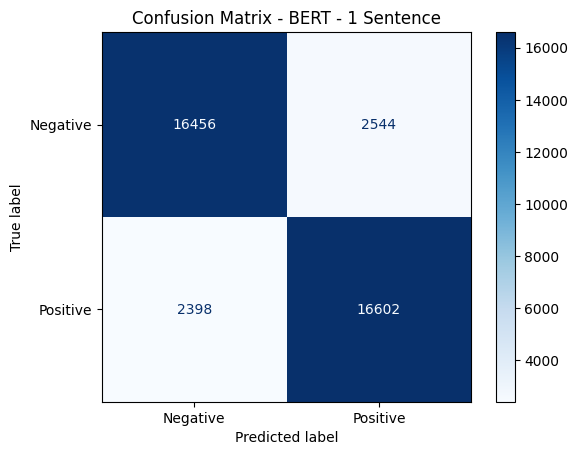

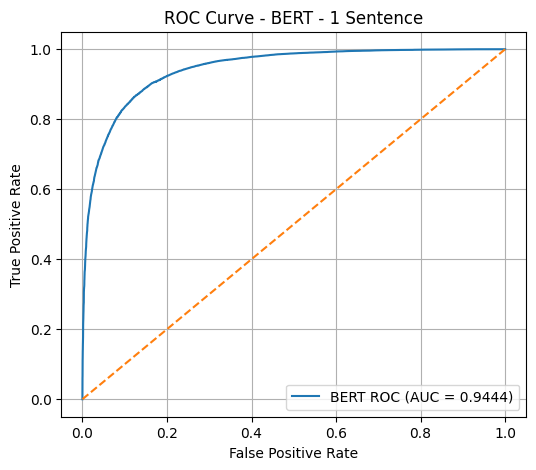

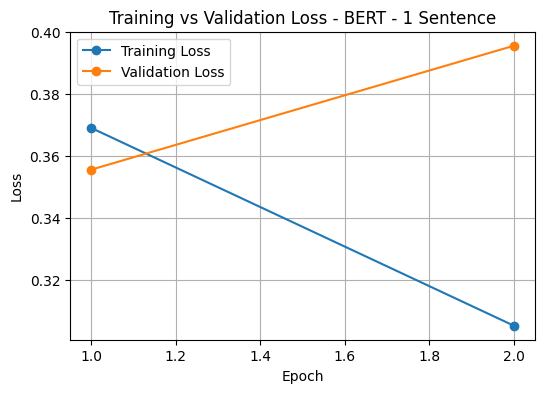


RUNNING: XLNet | Summarised Text | LSA | 1 Sentence


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 26.98
Train avg tokens after trunc: 26.84
Train truncation %: 0.12
Validation avg tokens after trunc: 26.63
Test avg tokens after trunc: 26.8
Test truncation %: 0.12


...

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.377145,0.335651,0.865054,0.864520,0.865786,0.865152,0.939174
2,0.317539,0.371170,0.873339,0.867706,0.881000,0.874302,0.945434


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.8726
Precision: 0.8675
Recall: 0.8794
F1: 0.8734
ROC-AUC: 0.9454
Training time: 165 min 3.67 sec
Training time per epoch: 82 min 31.83 sec
Inference time: 1 min 54.59 sec
Inference latency per sample (ms): 3.0154
Training throughput (samples/sec): 50.89
Inference throughput (samples/sec): 331.63
Peak training GPU memory (MB): 3185.86
Peak inference GPU memory (MB): 1753.43

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.87     19000
    Positive       0.87      0.88      0.87     19000

    accuracy                           0.87     38000
   macro avg       0.87      0.87      0.87     38000
weighted avg       0.87      0.87      0.87     38000



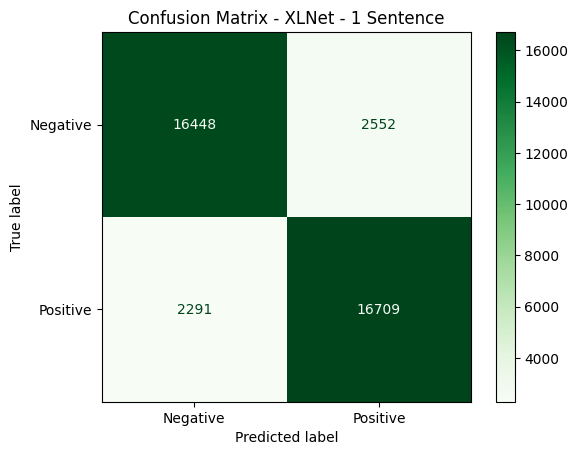

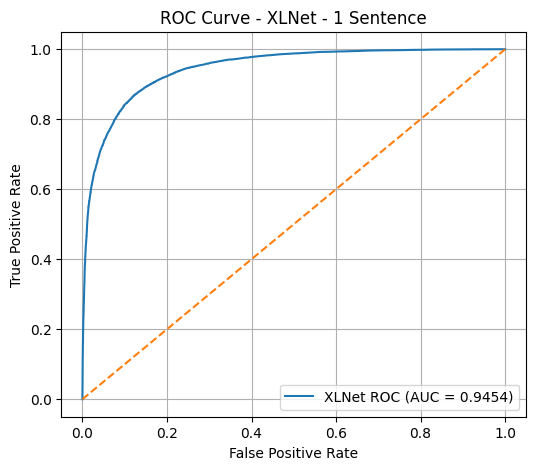

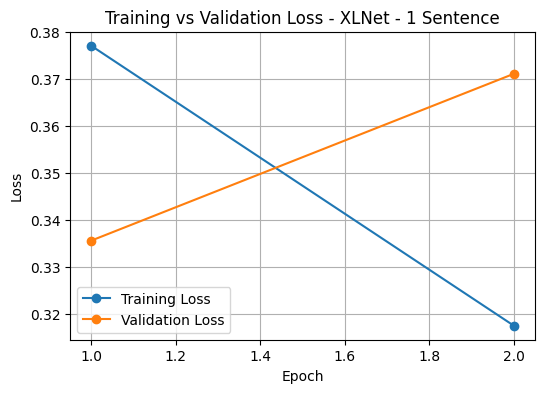


RUNNING: BERT | Summarised Text | LSA | 3 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (532 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 66.37
Train avg tokens after trunc: 65.83
Train truncation %: 0.56
Validation avg tokens after trunc: 65.54
Test avg tokens after trunc: 65.95
Test truncation %: 0.55


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.246217,0.239609,0.937161,0.929446,0.946143,0.937720,0.984104
2,0.163740,0.236898,0.944464,0.947565,0.941000,0.944271,0.986616


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9443
Precision: 0.9458
Recall: 0.9426
F1: 0.9442
ROC-AUC: 0.9868
Training time: 115 min 29.66 sec
Training time per epoch: 57 min 44.83 sec
Inference time: 1 min 20.53 sec
Inference latency per sample (ms): 2.1192
Training throughput (samples/sec): 72.73
Inference throughput (samples/sec): 471.87
Peak training GPU memory (MB): 2321.78
Peak inference GPU memory (MB): 1529.99

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.94     19000
    Positive       0.95      0.94      0.94     19000

    accuracy                           0.94     38000
   macro avg       0.94      0.94      0.94     38000
weighted avg       0.94      0.94      0.94     38000



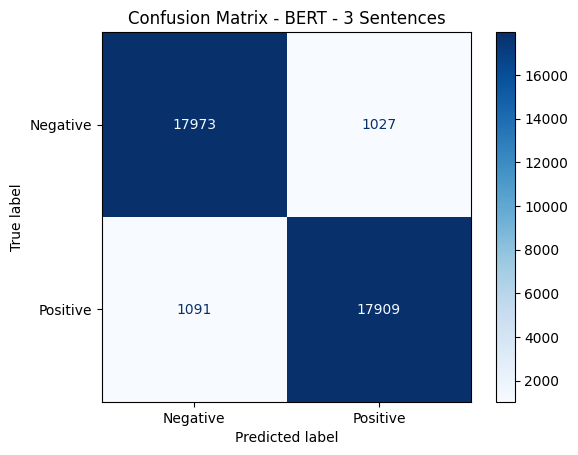

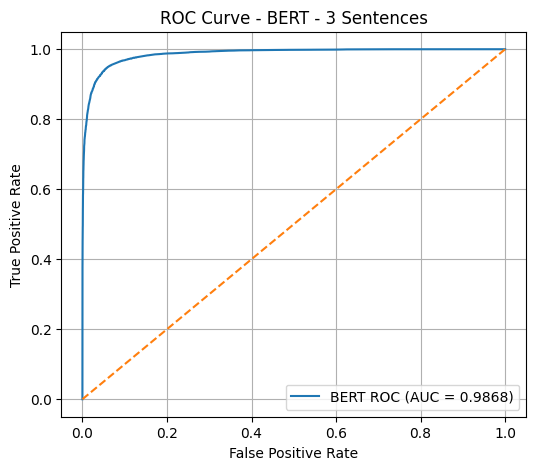

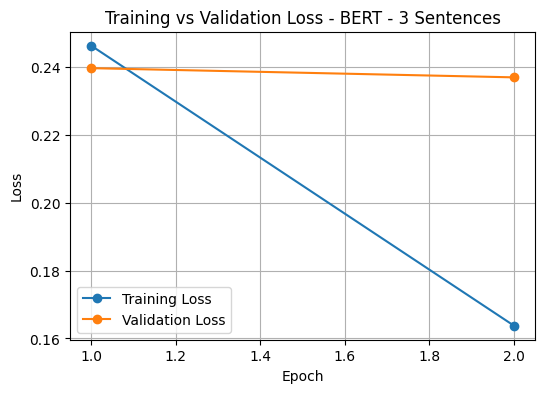


RUNNING: XLNet | Summarised Text | LSA | 3 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 68.84
Train avg tokens after trunc: 68.15
Train truncation %: 0.71
Validation avg tokens after trunc: 67.84
Test avg tokens after trunc: 68.25
Test truncation %: 0.69


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.254965,0.220436,0.941196,0.947024,0.934679,0.940811,0.984998
2,0.180240,0.218064,0.946554,0.945488,0.947750,0.946617,0.987345


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9453
Precision: 0.9431
Recall: 0.9478
F1: 0.9455
ROC-AUC: 0.9874
Training time: 169 min 55.02 sec
Training time per epoch: 84 min 57.51 sec
Inference time: 2 min 4.05 sec
Inference latency per sample (ms): 3.2645
Training throughput (samples/sec): 49.44
Inference throughput (samples/sec): 306.32
Peak training GPU memory (MB): 3179.83
Peak inference GPU memory (MB): 1754.17

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.95      0.94      0.95     19000
    Positive       0.94      0.95      0.95     19000

    accuracy                           0.95     38000
   macro avg       0.95      0.95      0.95     38000
weighted avg       0.95      0.95      0.95     38000



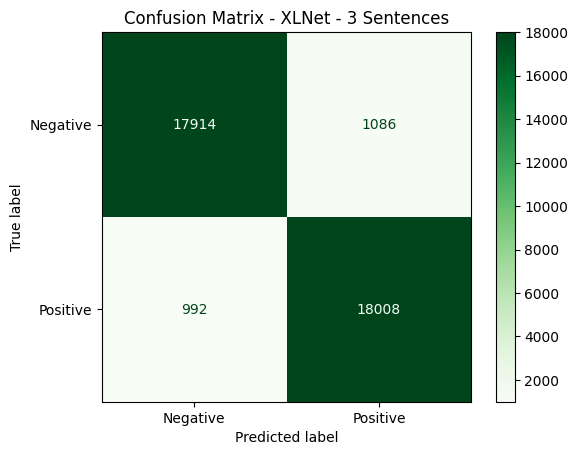

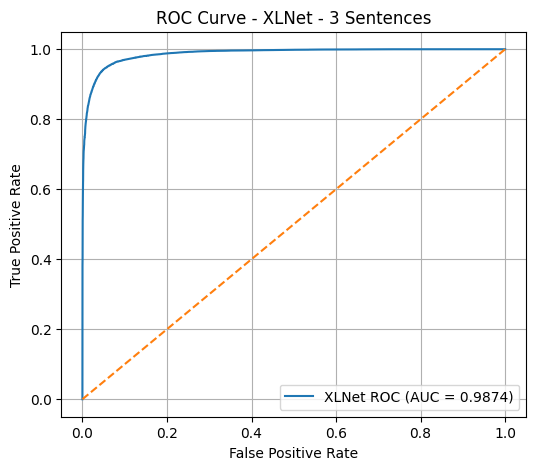

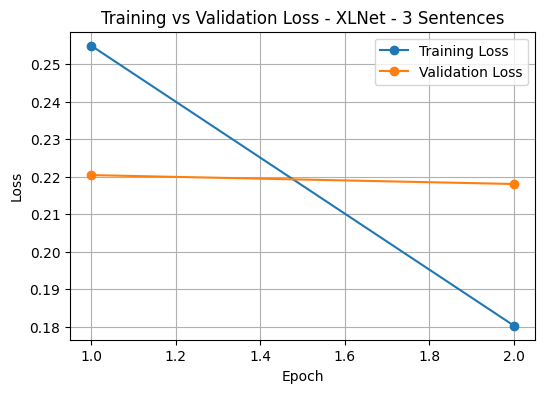


RUNNING: BERT | Summarised Text | LSA | 5 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (621 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 98.52
Train avg tokens after trunc: 97.11
Train truncation %: 1.84
Validation avg tokens after trunc: 96.87
Test avg tokens after trunc: 97.31
Test truncation %: 1.82


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.186892,0.150140,0.957643,0.952568,0.963250,0.957879,0.992154
2,0.108957,0.180522,0.961304,0.963938,0.958464,0.961193,0.993013


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9636
Precision: 0.9658
Recall: 0.9613
F1: 0.9635
ROC-AUC: 0.9937
Training time: 118 min 44.30 sec
Training time per epoch: 59 min 22.15 sec
Inference time: 1 min 22.67 sec
Inference latency per sample (ms): 2.1755
Training throughput (samples/sec): 70.74
Inference throughput (samples/sec): 459.67
Peak training GPU memory (MB): 2327.19
Peak inference GPU memory (MB): 1532.23

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.96      0.97      0.96     19000
    Positive       0.97      0.96      0.96     19000

    accuracy                           0.96     38000
   macro avg       0.96      0.96      0.96     38000
weighted avg       0.96      0.96      0.96     38000



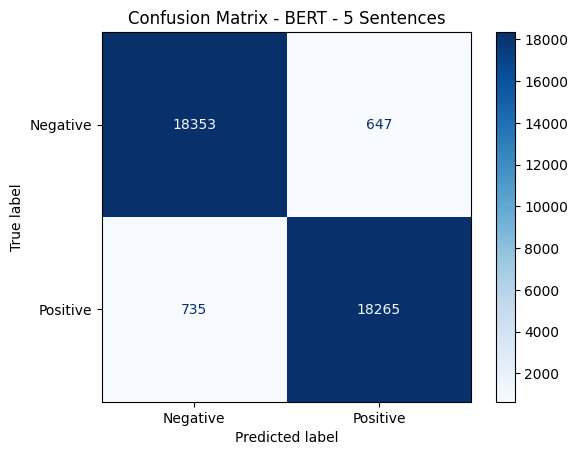

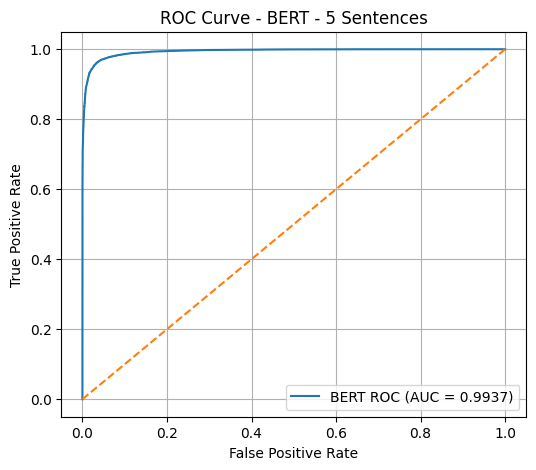

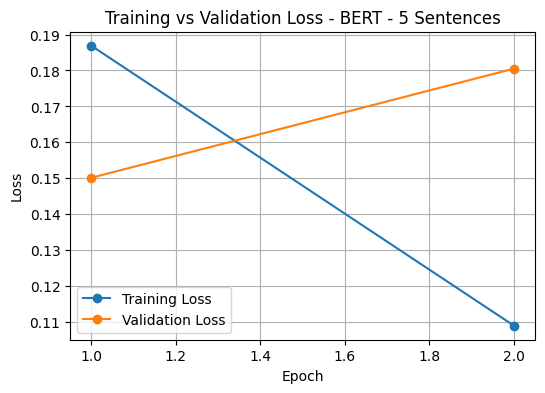


RUNNING: XLNet | Summarised Text | LSA | 5 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 102.15
Train avg tokens after trunc: 100.32
Train truncation %: 2.23
Validation avg tokens after trunc: 100.06
Test avg tokens after trunc: 100.51
Test truncation %: 2.25


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.190337,0.165189,0.954518,0.940318,0.970643,0.955240,0.991914
2,0.121412,0.154250,0.964536,0.966000,0.962964,0.964480,0.993867


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9657
Precision: 0.9674
Recall: 0.9639
F1: 0.9656
ROC-AUC: 0.9943
Training time: 175 min 28.28 sec
Training time per epoch: 87 min 44.14 sec
Inference time: 2 min 11.23 sec
Inference latency per sample (ms): 3.4533
Training throughput (samples/sec): 47.87
Inference throughput (samples/sec): 289.57
Peak training GPU memory (MB): 3192.83
Peak inference GPU memory (MB): 1758.27

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.96      0.97      0.97     19000
    Positive       0.97      0.96      0.97     19000

    accuracy                           0.97     38000
   macro avg       0.97      0.97      0.97     38000
weighted avg       0.97      0.97      0.97     38000



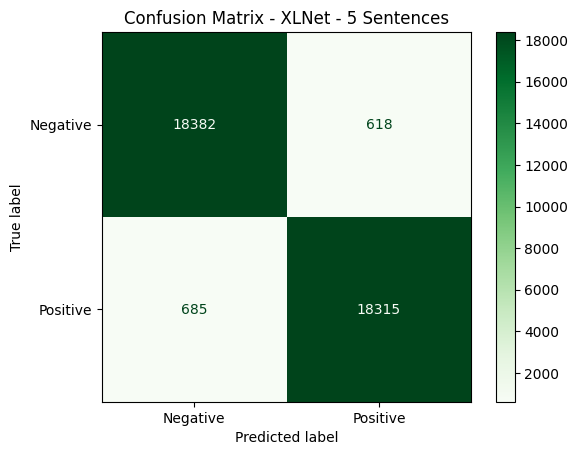

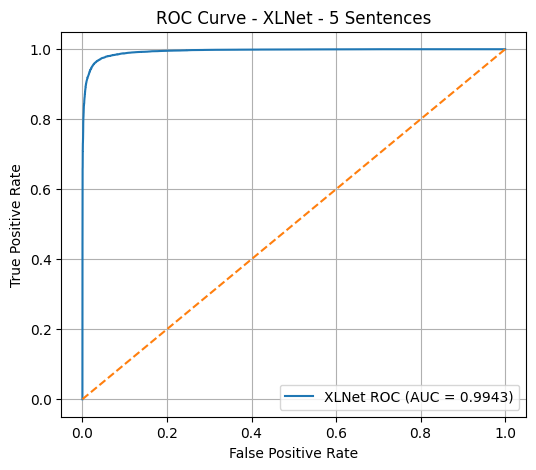

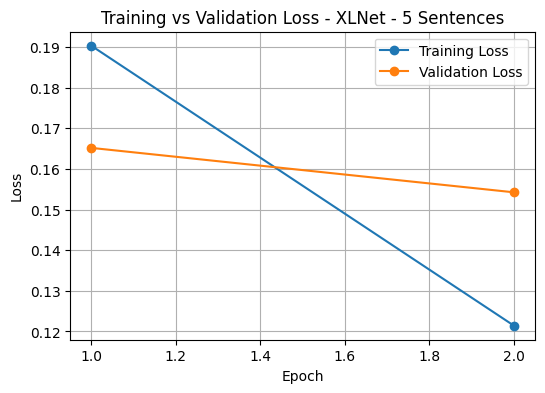


RUNNING: BERT | Summarised Text | LSA | 7 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (656 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 121.35
Train avg tokens after trunc: 118.03
Train truncation %: 4.76
Validation avg tokens after trunc: 117.76
Test avg tokens after trunc: 118.09
Test truncation %: 4.68


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.162784,0.131097,0.966089,0.974374,0.957357,0.965791,0.994483
2,0.090344,0.142796,0.969625,0.970987,0.968179,0.969581,0.995608


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9698
Precision: 0.971
Recall: 0.9685
F1: 0.9698
ROC-AUC: 0.9958
Training time: 120 min 28.54 sec
Training time per epoch: 60 min 14.27 sec
Inference time: 1 min 24.16 sec
Inference latency per sample (ms): 2.2146
Training throughput (samples/sec): 69.72
Inference throughput (samples/sec): 451.55
Peak training GPU memory (MB): 2323.82
Peak inference GPU memory (MB): 1526.46

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97     19000
    Positive       0.97      0.97      0.97     19000

    accuracy                           0.97     38000
   macro avg       0.97      0.97      0.97     38000
weighted avg       0.97      0.97      0.97     38000



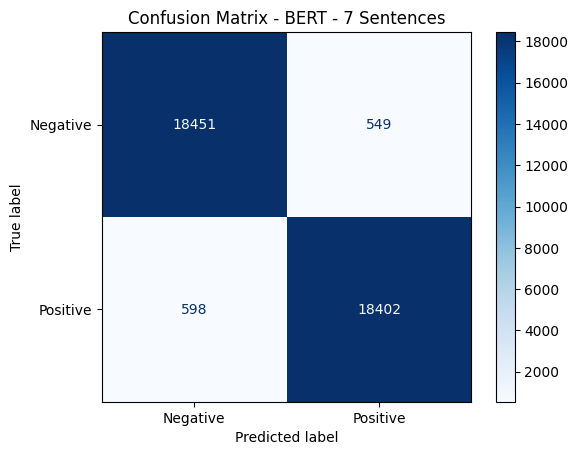

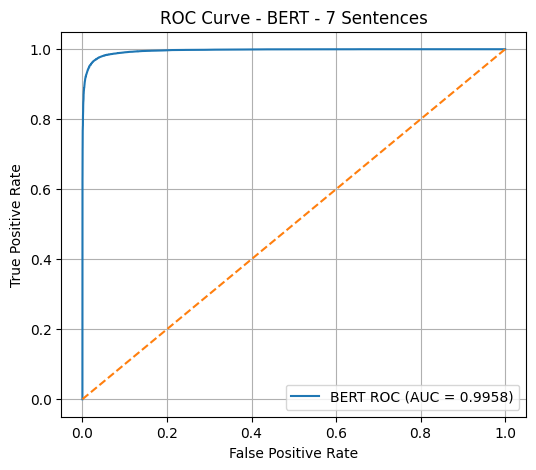

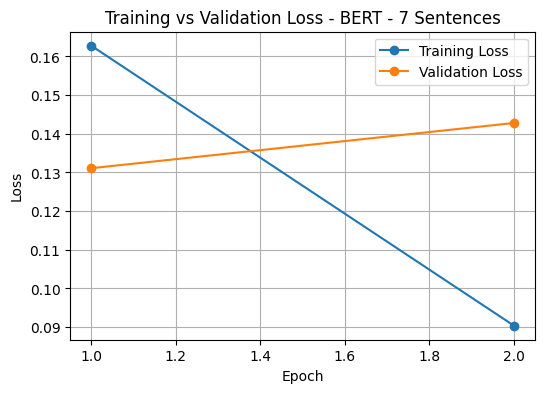


RUNNING: XLNet | Summarised Text | LSA | 7 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 125.79
Train avg tokens after trunc: 121.62
Train truncation %: 5.63
Validation avg tokens after trunc: 121.33
Test avg tokens after trunc: 121.68
Test truncation %: 5.52


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 
logits_proj.weight              | MISSING    | 
logits_proj.bias                | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.162952,0.136710,0.964750,0.956853,0.973393,0.965052,0.993902
2,0.100851,0.124314,0.970750,0.968741,0.972893,0.970813,0.995879


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.971
Precision: 0.9682
Recall: 0.974
F1: 0.9711
ROC-AUC: 0.9961
Training time: 178 min 43.19 sec
Training time per epoch: 89 min 21.59 sec
Inference time: 2 min 13.55 sec
Inference latency per sample (ms): 3.5146
Training throughput (samples/sec): 47.0
Inference throughput (samples/sec): 284.53
Peak training GPU memory (MB): 3183.86
Peak inference GPU memory (MB): 1754.93

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.97      0.97      0.97     19000
    Positive       0.97      0.97      0.97     19000

    accuracy                           0.97     38000
   macro avg       0.97      0.97      0.97     38000
weighted avg       0.97      0.97      0.97     38000



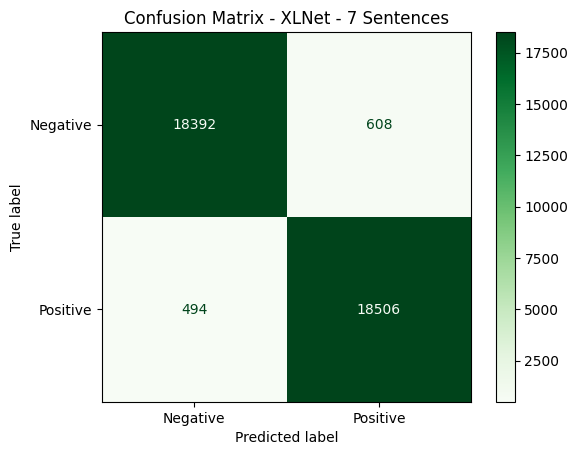

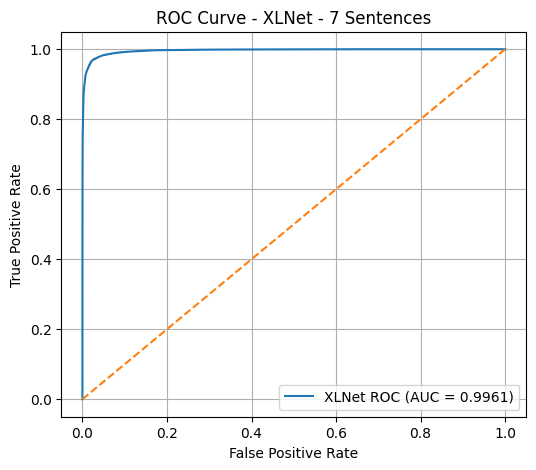

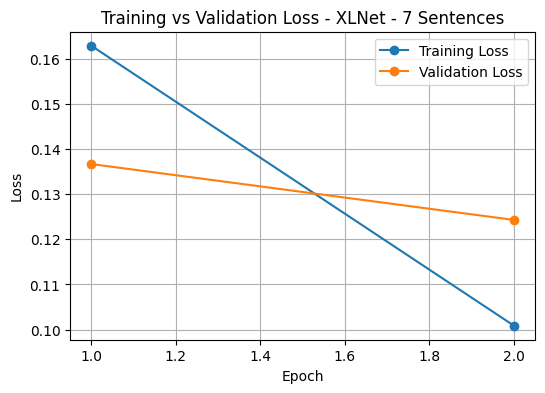


FINAL LSA CLASSIFICATION RESULTS


,Input Type,Summary Method,Summary Length,Model,Checkpoint,Optimizer,Max Length,Batch Size,Epochs,Learning Rate,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,LSA,1 Sentence,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,0.10,111.08,55.54,75.23,1.9797,75.62,505.13,2325.52,1529.26,NVIDIA A100-SXM4-40GB
1,Summarised Text,LSA,1 Sentence,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,0.12,165.06,82.53,114.59,3.0154,50.89,331.63,3185.86,1753.43,NVIDIA A100-SXM4-40GB
2,Summarised Text,LSA,3 Sentences,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,0.55,115.49,57.75,80.53,2.1192,72.73,471.87,2321.78,1529.99,NVIDIA A100-SXM4-40GB
3,Summarised Text,LSA,3 Sentences,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,0.69,169.92,84.96,124.05,3.2645,49.44,306.32,3179.83,1754.17,NVIDIA A100-SXM4-40GB
4,Summarised Text,LSA,5 Sentences,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,1.82,118.74,59.37,82.67,2.1755,70.74,459.67,2327.19,1532.23,NVIDIA A100-SXM4-40GB
5,Summarised Text,LSA,5 Sentences,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,2.25,175.47,87.74,131.23,3.4533,47.87,289.57,3192.83,1758.27,NVIDIA A100-SXM4-40GB
6,Summarised Text,LSA,7 Sentences,BERT,bert-base-uncased,AdamW,256,8,2,0.00002,...,4.68,120.48,60.24,84.16,2.2146,69.72,451.55,2323.82,1526.46,NVIDIA A100-SXM4-40GB
7,Summarised Text,LSA,7 Sentences,XLNet,xlnet-base-cased,AdamW,256,8,2,0.00002,...,5.52,178.72,89.36,133.55,3.5146,47.00,284.53,3183.86,1754.93,NVIDIA A100-SXM4-40GB



Saved: /content/drive/MyDrive/yelp_lsa_classification_outputs/lsa_classification_results.csv


In [ ]:
# =====================================================
# PART 2: YELP LSA SUMMARY CLASSIFICATION
# READ FROM GOOGLE DRIVE
# MODELS: BERT + XLNet
# INPUTS: 1, 3, 5, 7 SENTENCE SUMMARIES
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import re
import time
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")

# -------------------------
# REPRODUCIBILITY
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

# -------------------------
# PATHS
# -------------------------
BASE_DIR = "/content/drive/MyDrive/yelp_lsa_outputs"
RUN_OUTPUT_DIR = "/content/drive/MyDrive/yelp_lsa_classification_outputs"
os.makedirs(RUN_OUTPUT_DIR, exist_ok=True)

print("Reading files from:", BASE_DIR)
print("Saving outputs to:", RUN_OUTPUT_DIR)

# -------------------------
# HYPERPARAMETERS
# -------------------------
MAX_LENGTH = 256
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
BATCH_SIZE = 8
EARLY_STOPPING_PATIENCE = 1
OPTIMIZER_NAME = "AdamW"

# -------------------------
# DATASET CLASS
# -------------------------
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# -------------------------
# METRICS
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# -------------------------
# UTILITIES
# -------------------------
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None

def format_seconds(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"

@dataclass
class TokenStats:
    avg_tokens_before: float
    avg_tokens_after: float
    max_tokens_before: int
    truncated_count: int
    truncation_pct: float

def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = TokenStats(
        avg_tokens_before=float(np.mean(full_lengths)),
        avg_tokens_after=float(np.mean(trunc_lengths)),
        max_tokens_before=int(np.max(full_lengths)),
        truncated_count=int(truncated_count),
        truncation_pct=float(truncated_count / len(full_lengths) * 100)
    )

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc

def plot_confusion_matrix_save(y_true, y_pred, title, cmap, save_path):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=cmap)
    plt.title(title)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()
    return cm

def plot_roc_curve_save(y_true, y_prob, title, label_name, save_path):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_train_val_loss_save(trainer, title, save_path):
    history = trainer.state.log_history
    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log and "eval_loss" not in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    if len(train_loss) == 0 or len(val_loss) == 0:
        print("Skipping loss plot: insufficient log history.")
        return

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------
# LOAD SUMMARY CSV FILES
# -------------------------
def load_summary_split(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        if "summary_text" not in df.columns or "label" not in df.columns:
            raise ValueError(f"{name} file must contain columns: summary_text, label")

    train_texts = train_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()
    val_texts = val_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()
    test_texts = test_df["summary_text"].fillna("").astype(str).apply(clean_text).tolist()

    train_labels = train_df["label"].astype(int).tolist()
    val_labels = val_df["label"].astype(int).tolist()
    test_labels = test_df["label"].astype(int).tolist()

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# -------------------------
# EXPERIMENT FUNCTION
# -------------------------
def run_experiment(
    model_name,
    model_label,
    input_type,
    summary_method,
    summary_length,
    train_texts,
    val_texts,
    test_texts,
    train_labels,
    val_labels,
    test_labels,
    output_dir,
    max_length=256,
    batch_size=8
):
    os.makedirs(output_dir, exist_ok=True)

    print(f"\n{'='*80}")
    print(f"RUNNING: {model_label} | {input_type} | {summary_method} | {summary_length}")
    print(f"{'='*80}")

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

    train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=max_length)
    val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=max_length)
    test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=max_length)

    print("\n=== TOKEN / TRUNCATION STATS ===")
    print("Train avg tokens before trunc:", round(train_stats.avg_tokens_before, 2))
    print("Train avg tokens after trunc:", round(train_stats.avg_tokens_after, 2))
    print("Train truncation %:", round(train_stats.truncation_pct, 2))
    print("Validation avg tokens after trunc:", round(val_stats.avg_tokens_after, 2))
    print("Test avg tokens after trunc:", round(test_stats.avg_tokens_after, 2))
    print("Test truncation %:", round(test_stats.truncation_pct, 2))

    train_dataset = TextDataset(train_enc, train_labels)
    val_dataset = TextDataset(val_enc, val_labels)
    test_dataset = TextDataset(test_enc, test_labels)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=2,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        optim="adamw_torch"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)]
    )

    # -------- TRAINING --------
    reset_gpu_memory()
    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    peak_train_mem = get_peak_gpu_memory_mb()

    # -------- INFERENCE --------
    reset_gpu_memory()
    infer_start = time.time()
    pred = trainer.predict(test_dataset)
    infer_time = time.time() - infer_start
    peak_infer_mem = get_peak_gpu_memory_mb()

    y_true = np.array(test_labels)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_value = roc_auc_score(y_true, y_prob)

    num_train = len(train_dataset)
    num_test = len(test_dataset)

    train_time_per_epoch = train_time / int(args.num_train_epochs)
    train_samples_per_sec = num_train / train_time
    infer_samples_per_sec = num_test / infer_time
    infer_latency_per_sample_ms = (infer_time / num_test) * 1000

    print("\n=== RESULTS ===")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc_value, 4))
    print("Training time:", format_seconds(train_time))
    print("Training time per epoch:", format_seconds(train_time_per_epoch))
    print("Inference time:", format_seconds(infer_time))
    print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
    print("Training throughput (samples/sec):", round(train_samples_per_sec, 2))
    print("Inference throughput (samples/sec):", round(infer_samples_per_sec, 2))
    print("Peak training GPU memory (MB):", round(peak_train_mem, 2) if peak_train_mem is not None else "N/A")
    print("Peak inference GPU memory (MB):", round(peak_infer_mem, 2) if peak_infer_mem is not None else "N/A")

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0,
        output_dict=True
    )

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    prefix = f"{model_label.lower()}_{summary_length.replace(' ', '_').lower()}"

    cm_path = os.path.join(output_dir, f"{prefix}_confusion_matrix.png")
    roc_path = os.path.join(output_dir, f"{prefix}_roc_curve.png")
    loss_path = os.path.join(output_dir, f"{prefix}_train_val_loss.png")

    cm = plot_confusion_matrix_save(
        y_true, y_pred,
        f"Confusion Matrix - {model_label} - {summary_length}",
        "Blues" if model_label == "BERT" else "Greens",
        cm_path
    )

    plot_roc_curve_save(
        y_true, y_prob,
        f"ROC Curve - {model_label} - {summary_length}",
        f"{model_label} ROC",
        roc_path
    )

    plot_train_val_loss_save(
        trainer,
        f"Training vs Validation Loss - {model_label} - {summary_length}",
        loss_path
    )

    pd.DataFrame(report_dict).transpose().to_csv(
        os.path.join(output_dir, f"{prefix}_classification_report.csv")
    )

    pd.DataFrame(
        cm,
        index=["Actual_Negative", "Actual_Positive"],
        columns=["Pred_Negative", "Pred_Positive"]
    ).to_csv(
        os.path.join(output_dir, f"{prefix}_confusion_matrix_values.csv")
    )

    pd.DataFrame(trainer.state.log_history).to_csv(
        os.path.join(output_dir, f"{prefix}_training_log_history.csv"),
        index=False
    )

    pd.DataFrame({
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_positive": y_prob
    }).to_csv(
        os.path.join(output_dir, f"{prefix}_test_predictions.csv"),
        index=False
    )

    results = {
        "Input Type": input_type,
        "Summary Method": summary_method,
        "Summary Length": summary_length,
        "Model": model_label,
        "Checkpoint": model_name,
        "Optimizer": OPTIMIZER_NAME,
        "Max Length": max_length,
        "Batch Size": batch_size,
        "Epochs": EPOCHS,
        "Learning Rate": LEARNING_RATE,
        "Weight Decay": WEIGHT_DECAY,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc_value, 4),
        "Train Samples": num_train,
        "Validation Samples": len(val_dataset),
        "Test Samples": num_test,
        "Avg Train Tokens Before Trunc": round(train_stats.avg_tokens_before, 2),
        "Avg Train Tokens After Trunc": round(train_stats.avg_tokens_after, 2),
        "Avg Test Tokens Before Trunc": round(test_stats.avg_tokens_before, 2),
        "Avg Test Tokens After Trunc": round(test_stats.avg_tokens_after, 2),
        "Train Truncated Count": train_stats.truncated_count,
        "Test Truncated Count": test_stats.truncated_count,
        "Train Truncation %": round(train_stats.truncation_pct, 2),
        "Test Truncation %": round(test_stats.truncation_pct, 2),
        "Training Time (min)": round(train_time / 60, 2),
        "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
        "Inference Time (sec)": round(infer_time, 2),
        "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
        "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
        "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
        "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
        "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
        "Device": device_name
    }

    pd.DataFrame([results]).to_csv(
        os.path.join(output_dir, f"{prefix}_metrics.csv"),
        index=False
    )

    del model, trainer, train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

# -------------------------
# FILE CONFIGURATION
# -------------------------
summary_configs = [
    {
        "summary_length": "1 Sentence",
        "train_path": f"{BASE_DIR}/train_lsa_1_sentences.csv",
        "val_path": f"{BASE_DIR}/val_lsa_1_sentences.csv",
        "test_path": f"{BASE_DIR}/test_lsa_1_sentences.csv",
    },
    {
        "summary_length": "3 Sentences",
        "train_path": f"{BASE_DIR}/train_lsa_3_sentences.csv",
        "val_path": f"{BASE_DIR}/val_lsa_3_sentences.csv",
        "test_path": f"{BASE_DIR}/test_lsa_3_sentences.csv",
    },
    {
        "summary_length": "5 Sentences",
        "train_path": f"{BASE_DIR}/train_lsa_5_sentences.csv",
        "val_path": f"{BASE_DIR}/val_lsa_5_sentences.csv",
        "test_path": f"{BASE_DIR}/test_lsa_5_sentences.csv",
    },
    {
        "summary_length": "7 Sentences",
        "train_path": f"{BASE_DIR}/train_lsa_7_sentences.csv",
        "val_path": f"{BASE_DIR}/val_lsa_7_sentences.csv",
        "test_path": f"{BASE_DIR}/test_lsa_7_sentences.csv",
    }
]

# -------------------------
# CHECK FILES EXIST
# -------------------------
print("\nChecking files...\n")
for config in summary_configs:
    for key in ["train_path", "val_path", "test_path"]:
        print(config[key], "->", os.path.exists(config[key]))

# -------------------------
# RUN ALL EXPERIMENTS
# -------------------------
all_results = []

for config in summary_configs:
    train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_summary_split(
        config["train_path"],
        config["val_path"],
        config["test_path"]
    )

    bert_result = run_experiment(
        model_name="bert-base-uncased",
        model_label="BERT",
        input_type="Summarised Text",
        summary_method="LSA",
        summary_length=config["summary_length"],
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"{RUN_OUTPUT_DIR}/bert_lsa_{config['summary_length'].replace(' ', '_').lower()}",
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE
    )
    all_results.append(bert_result)

    xlnet_result = run_experiment(
        model_name="xlnet-base-cased",
        model_label="XLNet",
        input_type="Summarised Text",
        summary_method="LSA",
        summary_length=config["summary_length"],
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"{RUN_OUTPUT_DIR}/xlnet_lsa_{config['summary_length'].replace(' ', '_').lower()}",
        max_length=MAX_LENGTH,
        batch_size=BATCH_SIZE
    )
    all_results.append(xlnet_result)

# -------------------------
# SAVE FINAL RESULTS
# -------------------------
results_df = pd.DataFrame(all_results)

print("\nFINAL LSA CLASSIFICATION RESULTS")
display(results_df)

final_results_path = f"{RUN_OUTPUT_DIR}/lsa_classification_results.csv"
results_df.to_csv(final_results_path, index=False)
print(f"\nSaved: {final_results_path}")